In [1]:
from torchvision import datasets
from torchvision.transforms import transforms

In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

full_train_data = datasets.MNIST(
    root="data",
    download=False,
    train=True,
    transform=transform,
)

test_data = datasets.MNIST(
    root="data", download=False, train=False, transform=transform
)

In [3]:
print("Full training set: ", len(full_train_data), "\nTesting set: ", len(test_data))

Full training set:  60000 
Testing set:  10000


In [4]:
from torch.utils.data import random_split

In [5]:
train_size = 50000
val_size = 10000

train_data, val_data = random_split(full_train_data, [train_size, val_size])

print(
    "Train set: ",
    len(train_data),
    "\nVal set: ",
    len(val_data),
    "\nTest set: ",
    len(test_data),
)

Train set:  50000 
Val set:  10000 
Test set:  10000


In [6]:
from torch.utils.data import DataLoader

In [7]:
train_loader = DataLoader(
    train_data, batch_size=64, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

In [8]:
import torchvision.models as models

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [10]:
import torch.nn as nn

In [11]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [12]:
import torch
import torch.optim as optim

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

cuda
Epoch 1/5
Train - Loss: 0.0539 Acc: 0.9832
Val   - Loss: 0.0411 Acc: 0.9875
-------------------------
Epoch 2/5
Train - Loss: 0.0356 Acc: 0.9896
Val   - Loss: 0.0324 Acc: 0.9910
-------------------------
Epoch 3/5
Train - Loss: 0.0247 Acc: 0.9921
Val   - Loss: 0.0367 Acc: 0.9903
-------------------------
Epoch 4/5
Train - Loss: 0.0215 Acc: 0.9933
Val   - Loss: 0.0314 Acc: 0.9910
-------------------------
Epoch 5/5
Train - Loss: 0.0204 Acc: 0.9938
Val   - Loss: 0.0296 Acc: 0.9918
-------------------------

OVERALL ACCURACY: 0.9936

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
 

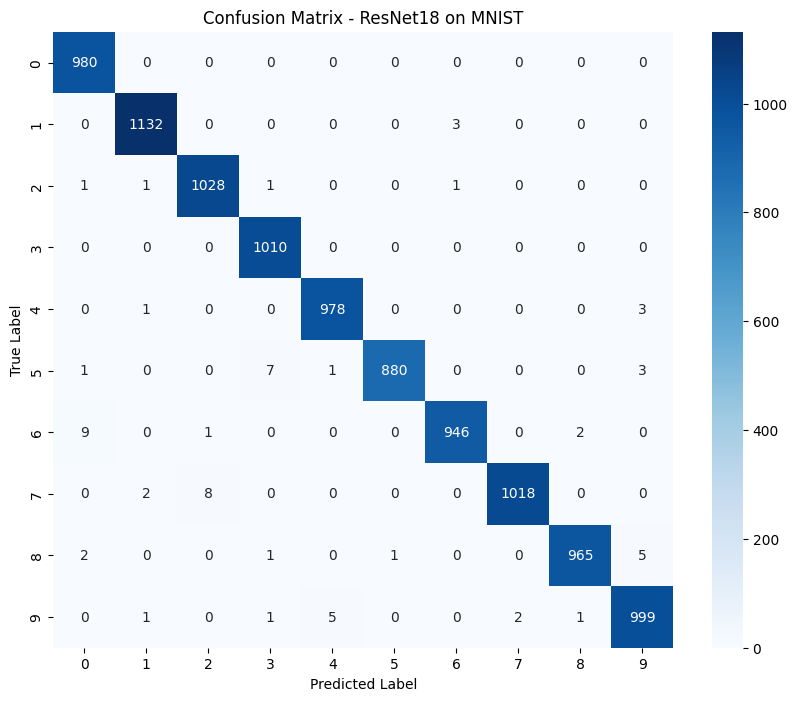

In [17]:
epochs = 5

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_corrects.double() / len(val_loader.dataset)

    # --- Print Epoch Metrics ---
    # Używamy f-stringów dla czytelności (4 miejsca po przecinku)
    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Train - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    print(f"Val   - Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    print("-" * 25)  # Separator dla przejrzystości


# --- Final Test Phase ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Obliczanie metryk
accuracy = accuracy_score(all_labels, all_preds)
report = classification_report(
    all_labels, all_preds, target_names=[str(i) for i in range(10)]
)

print("\n" + "=" * 30)
print(f"OVERALL ACCURACY: {accuracy:.4f}")
print("=" * 30)
print("\nCLASSIFICATION REPORT:\n")
print(report)

# 3. Generowanie Macierzy Pomyłek (Heatmap)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)],
)
plt.title("Confusion Matrix - ResNet18 on MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [18]:
from pathlib import Path

In [19]:
model_path = Path("models/resnet18_mnist_trained.pth")
torch.save(model.state_dict(), model_path)